# JMAIL Pipeline Processing

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import dotenv_values

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

ENV_PATH = PROJECT_ROOT / ".env"
ENV = dotenv_values(ENV_PATH)


def _resolve(key, default):
    v = ENV.get(key, default)
    p = Path(v)
    return p if p.is_absolute() else PROJECT_ROOT / p


SAMPLE_SIZE = int(ENV.get("PROCESSING_SAMPLE_SIZE", "1000"))

RAW_SAMPLE_PATH = _resolve("DATA_RAW_PATH", "data/raw/") / ENV.get(
    "RAW_EMAILS_SAMPLE_FILENAME", "jmail_emails_sample.parquet"
)
PROCESSED_SAMPLE_PATH = _resolve("DATA_PROCESSED_PATH", "data/processed/") / ENV.get(
    "PROCESSED_EMAILS_SAMPLE_FILENAME", "jmail_emails_processed_sample.parquet"
)
RAW_PROFILING_PATH = _resolve("METADATA_PATH", "data/metadata/") / "profiling/raw/profile.json"
PROCESSED_PROFILING_PATH = _resolve("METADATA_PATH", "data/metadata/") / "profiling/processed/profile.json"

plt.style.use("default")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 200)

# Sample Raw

In [2]:
from src.utils.data_extraction import run_extraction

extraction_result = run_extraction(env_file=str(ENV_PATH), sample_limit=SAMPLE_SIZE)
extraction_result

{'endpoint': 'v1/emails.parquet',
 'raw_output_path': 'data/raw/jmail_emails.parquet',
 'metadata_output_path': 'data/metadata/jmail_extraction_metadata.json',
 'sample_output_path': 'data/raw/jmail_emails_sample.parquet',
 'row_count': 1783792,
 'column_count': 19}

In [3]:
from src.utils.data_profiling import profile_parquet, write_profile

raw_profile = profile_parquet(RAW_SAMPLE_PATH)
write_profile(raw_profile, RAW_PROFILING_PATH)

print(f"Shape: {raw_profile['row_count']} rows × {raw_profile['column_count']} columns")

Shape: 10000 rows × 19 columns


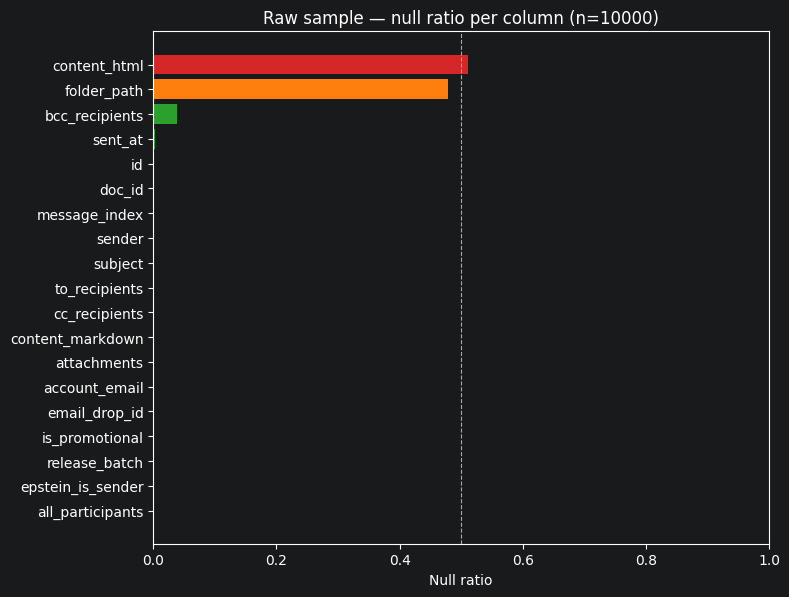

In [4]:
cols_data = sorted(
    [(c["name"], c["null_ratio"] or 0) for c in raw_profile["columns"]],
    key=lambda x: x[1],
    reverse=True,
)
names, ratios = zip(*cols_data)

fig, ax = plt.subplots(figsize=(8, max(4, len(names) * 0.32)))
colors = ["#d62728" if r > 0.5 else "#ff7f0e" if r > 0.1 else "#2ca02c" for r in ratios]
ax.barh(names, ratios, color=colors)
ax.set_xlabel("Null ratio")
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.axvline(0.5, color="#aaa", linestyle="--", linewidth=0.8)
ax.set_title(f"Raw sample — null ratio per column (n={raw_profile['row_count']})")
plt.tight_layout()
plt.show()

# Processing

In [5]:
from src.utils.data_processing import run_processing_with_limit

processing_result = run_processing_with_limit(env_file=str(ENV_PATH), limit=SAMPLE_SIZE)
processing_result

{'raw_path': '/home/suga/Workspace/Projects/pizza-cluster/data/raw/jmail_emails.parquet',
 'processed_output_path': '/home/suga/Workspace/Projects/pizza-cluster/data/processed/jmail_emails_processed_sample.parquet',
 'metadata_output_path': '/home/suga/Workspace/Projects/pizza-cluster/data/metadata/jmail_processing_sample_metadata.json',
 'input_rows': 10000,
 'output_rows': 6335,
 'removed_promotional_rows': 3665,
 'removed_empty_text_rows': 0}

In [6]:
processed_profile = profile_parquet(PROCESSED_SAMPLE_PATH)
processed_profile["raw_source_path"] = str(RAW_SAMPLE_PATH)
write_profile(processed_profile, PROCESSED_PROFILING_PATH)

print(f"Shape: {processed_profile['row_count']} rows × {processed_profile['column_count']} columns")

Shape: 6335 rows × 34 columns


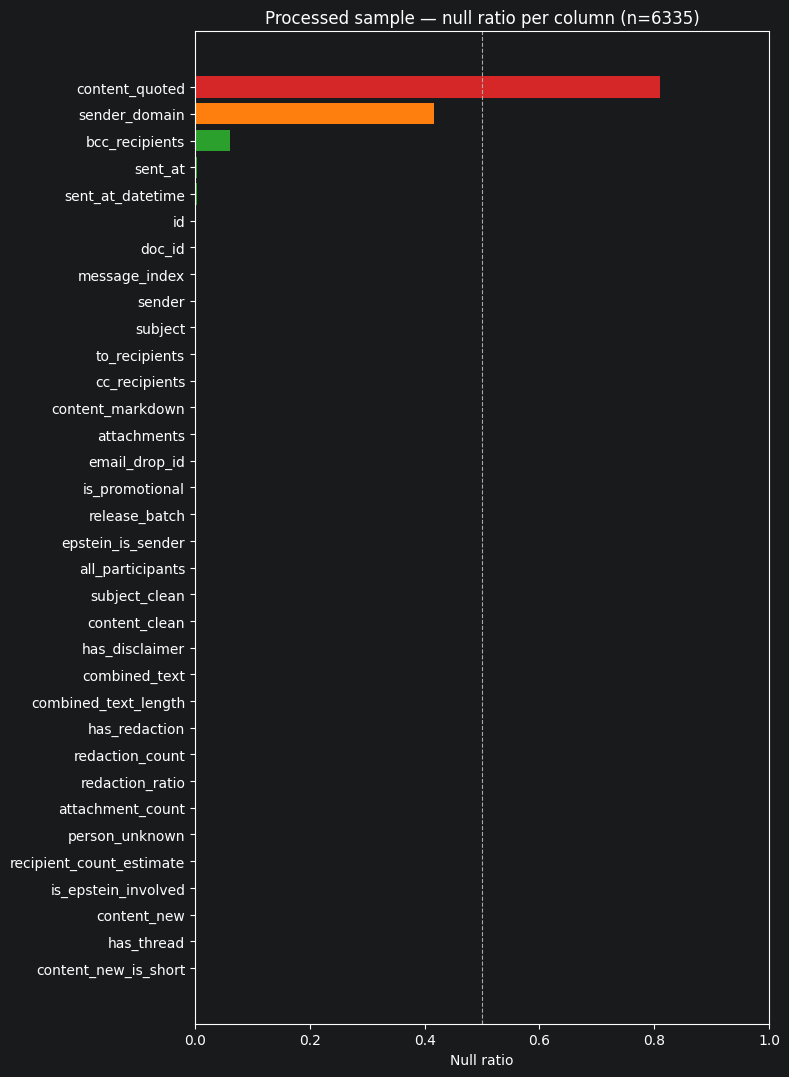

In [7]:
cols_data = sorted(
    [(c["name"], c["null_ratio"] or 0) for c in processed_profile["columns"]],
    key=lambda x: x[1],
    reverse=True,
)
names, ratios = zip(*cols_data)

fig, ax = plt.subplots(figsize=(8, max(4, len(names) * 0.32)))
colors = ["#d62728" if r > 0.5 else "#ff7f0e" if r > 0.1 else "#2ca02c" for r in ratios]
ax.barh(names, ratios, color=colors)
ax.set_xlabel("Null ratio")
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.axvline(0.5, color="#aaa", linestyle="--", linewidth=0.8)
ax.set_title(f"Processed sample — null ratio per column (n={processed_profile['row_count']})")
plt.tight_layout()
plt.show()

# Comparison

In [8]:
raw_df = pd.read_parquet(RAW_SAMPLE_PATH)
processed_df = pd.read_parquet(PROCESSED_SAMPLE_PATH)

rows_in = raw_profile["row_count"]
rows_out = processed_profile["row_count"]
rows_removed = rows_in - rows_out

summary = pd.DataFrame([
    {"dataset": "raw", "rows": rows_in, "columns": raw_profile["column_count"]},
    {"dataset": "processed", "rows": rows_out, "columns": processed_profile["column_count"]},
])
display(summary)
print(f"\nRows removed: {rows_removed} ({rows_removed / rows_in * 100:.1f}%)")

added_cols = sorted(set(processed_df.columns) - set(raw_df.columns))
removed_cols = sorted(set(raw_df.columns) - set(processed_df.columns))
if added_cols:
    print(f"Columns added:   {added_cols}")
if removed_cols:
    print(f"Columns removed: {removed_cols}")

,dataset,rows,columns
0,raw,10000,19
1,processed,6335,34



Rows removed: 3665 (36.6%)
Columns added:   ['attachment_count', 'combined_text', 'combined_text_length', 'content_clean', 'content_new', 'content_new_is_short', 'content_quoted', 'has_disclaimer', 'has_redaction', 'has_thread', 'is_epstein_involved', 'person_unknown', 'recipient_count_estimate', 'redaction_count', 'redaction_ratio', 'sender_domain', 'sent_at_datetime', 'subject_clean']
Columns removed: ['account_email', 'content_html', 'folder_path']


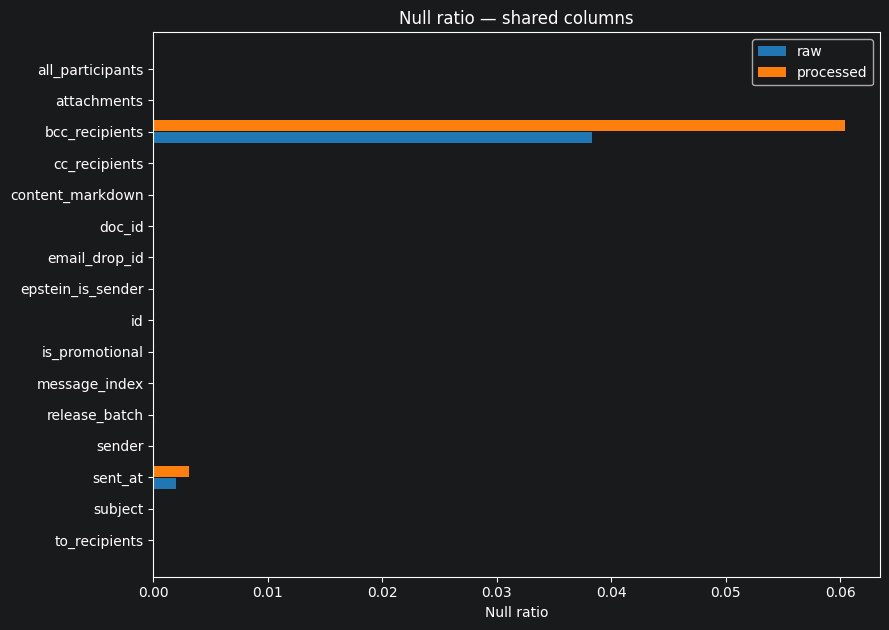

In [9]:
raw_nulls = {c["name"]: c["null_ratio"] or 0 for c in raw_profile["columns"]}
proc_nulls = {c["name"]: c["null_ratio"] or 0 for c in processed_profile["columns"]}
shared = sorted(set(raw_nulls) & set(proc_nulls))

y = range(len(shared))
fig, ax = plt.subplots(figsize=(9, max(4, len(shared) * 0.4)))
ax.barh([i + 0.2 for i in y], [raw_nulls[c] for c in shared], height=0.35, label="raw", color="#1f77b4")
ax.barh([i - 0.2 for i in y], [proc_nulls[c] for c in shared], height=0.35, label="processed", color="#ff7f0e")
ax.set_yticks(list(y))
ax.set_yticklabels(shared)
ax.set_xlabel("Null ratio")
ax.invert_yaxis()
ax.legend()
ax.set_title("Null ratio — shared columns")
plt.tight_layout()
plt.show()

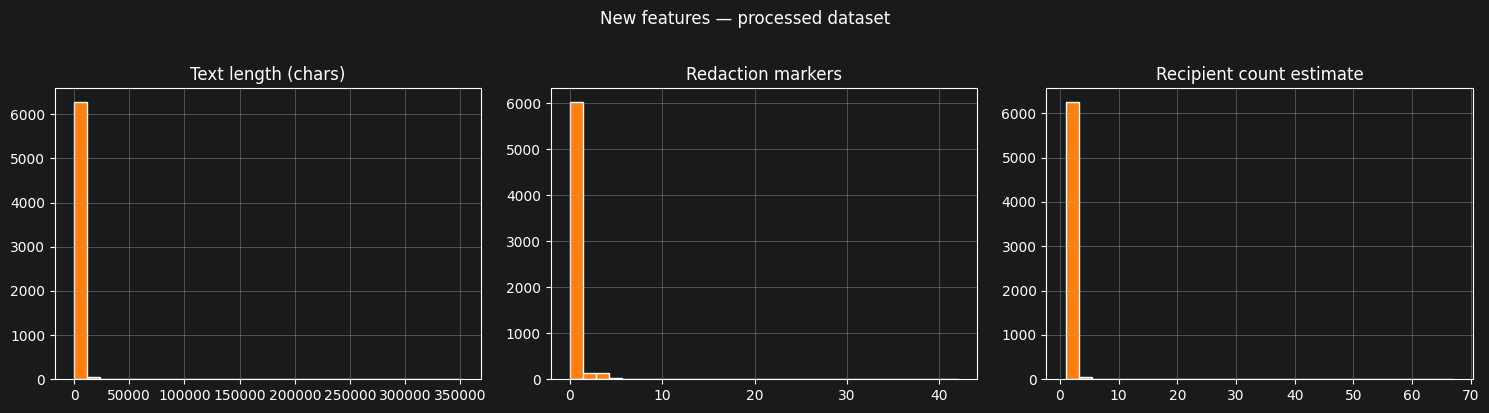

In [10]:
feature_cols = [
    ("combined_text_length", "Text length (chars)"),
    ("redaction_count", "Redaction markers"),
    ("recipient_count_estimate", "Recipient count estimate"),
]
available = [(col, label) for col, label in feature_cols if col in processed_df.columns]

fig, axes = plt.subplots(1, len(available), figsize=(5 * len(available), 4))
if len(available) == 1:
    axes = [axes]

for ax, (col, label) in zip(axes, available):
    processed_df[col].dropna().astype(float).hist(bins=30, ax=ax, color="#ff7f0e", edgecolor="white")
    ax.set_title(label)

plt.suptitle("New features — processed dataset", y=1.02)
plt.tight_layout()
plt.show()

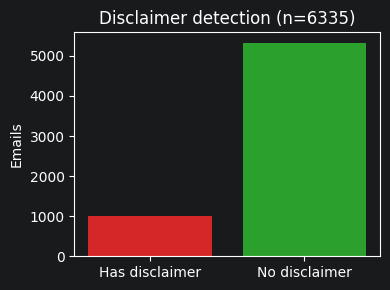

In [11]:
if "has_disclaimer" in processed_df.columns:
    counts = processed_df["has_disclaimer"].value_counts().reindex([True, False], fill_value=0)
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.bar(["Has disclaimer", "No disclaimer"], [counts[True], counts[False]], color=["#d62728", "#2ca02c"])
    ax.set_ylabel("Emails")
    ax.set_title(f"Disclaimer detection (n={len(processed_df)})")
    plt.tight_layout()
    plt.show()

Struttura del `combined_text` dopo l'applicazione del template di embedding.

In [12]:
for i, row in processed_df[["combined_text"]].head(100).iterrows():
    print(f"=== Row {i} ===")
    print(row["combined_text"][:400])
    print()

=== Row 0 ===
DATE: 2015-05-07T07:07:33.000Z
FROM: jeffrey E.  <jeevacation@gmail.com>
TO: ["Ehud Barak  <ehbarak1@gmail.com>"]
SUBJECT: Re: Title and subtitle

BODY:
prefer OUR COUNTRY , MY LIFE or MOMENTS

=== Row 1 ===
DATE: 2006-07-10T18:13:50.000Z
FROM: J. Epstein <jeeproject@yahoo.com>
TO: ["Cecilia Steen <cecilia.steen@gmail.com>"]
SUBJECT: Re: Barbro Ehnbom: SALSS 2006

BODY:
i'll try --- Cecilia Steen <cecilia.steen@gmail.com> wrote: > Dear Jeffrey, > > It would be great if you could come over for this > summit in Stockholm August > 16 - 18th. You will meet some of the best scientific > minds in Sweden, we

=== Row 2 ===
DATE: 2007-02-19T20:50:39.000Z
FROM: J. Epstein <jeeproject@yahoo.com>
TO: ["<gmax1@mindspring.com>"]
SUBJECT: Re:

BODY:
both ----- Original Message ---- From: Gmax <gmax1@mindspring.com> To: "Epstein, Jeffrey" <jeeproject@yahoo.com> Sent: Sunday, February 18, 2007 11:47:11 PM Subject: When to the Radar site - was it to see yucky pic of Flavio or article on w

# Thread Detection

Le colonne `content_new`, `content_quoted`, `has_thread`, `content_new_is_short` vengono prodotte da `add_thread_features()` durante `process_emails()`.

`add_thread_features` opera su `content_markdown` (raw, pre-normalizzazione) così che le ancore `^` in modalità MULTILINE nei pattern di rilevamento funzionino correttamente su ogni riga. `content_clean` (whitespace-collapsed da `normalize_text`) non è usata come fonte per questo step.

`content_new` contiene solo il testo del mittente corrente (thread/quote rimossi);
`content_quoted` è `null` se non è stato rilevato nessun marker.

In [13]:
_THREAD_COLS = ["content_new", "content_quoted", "has_thread", "content_new_is_short"]
_missing = [c for c in _THREAD_COLS if c not in processed_df.columns]

if _missing:
    print(f"Colonne mancanti: {_missing}")
    print("Ri-esegui la cella 'Processing' per rigenerare il parquet con le nuove colonne.")
else:
    n = len(processed_df)
    ht = processed_df["has_thread"].value_counts().reindex([True, False], fill_value=0)
    sh = processed_df["content_new_is_short"].value_counts().reindex([True, False], fill_value=0)

    stats = pd.DataFrame({
        "metrica": [
            "email con thread (has_thread=True)",
            "email senza thread (has_thread=False)",
            "content_new < 20 chars (is_short=True)",
            "content_new normale (is_short=False)",
        ],
        "count": [int(ht[True]), int(ht[False]), int(sh[True]), int(sh[False])],
        "%": [f"{v/n*100:.1f}%" for v in [int(ht[True]), int(ht[False]), int(sh[True]), int(sh[False])]],
    })
    display(stats)

,metrica,count,%
0,email con thread (has_thread=True),1202,19.0%
1,email senza thread (has_thread=False),5133,81.0%
2,content_new < 20 chars (is_short=True),946,14.9%
3,content_new normale (is_short=False),5389,85.1%


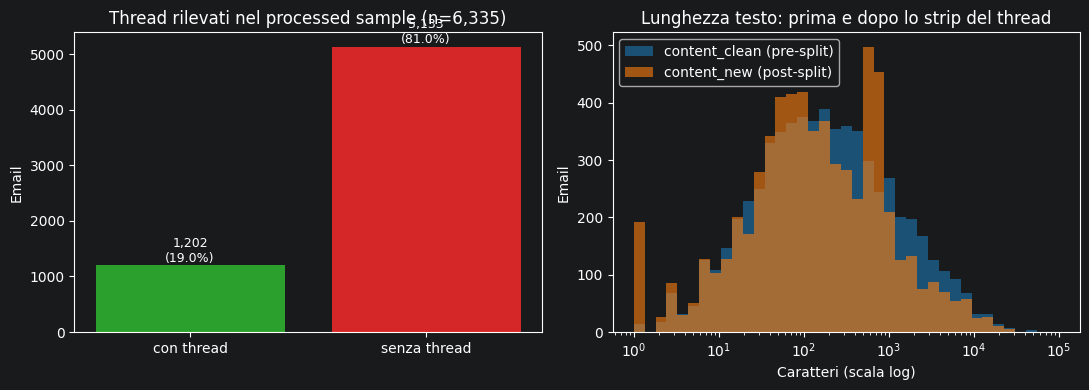

In [14]:
if not _missing:
    import numpy as np

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # Bar: has_thread True / False
    axes[0].bar(["con thread", "senza thread"], [int(ht[True]), int(ht[False])],
                color=["#2ca02c", "#d62728"])
    axes[0].set_ylabel("Email")
    axes[0].set_title(f"Thread rilevati nel processed sample (n={n:,})")
    for bar, val in zip(axes[0].patches, [int(ht[True]), int(ht[False])]):
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                     f"{val:,}\n({val/n*100:.1f}%)", ha="center", va="bottom", fontsize=9)

    # Istogramma lunghezza content_new vs content_clean
    len_new   = processed_df["content_new"].fillna("").str.len().clip(lower=1)
    len_clean = processed_df["content_clean"].fillna("").str.len().clip(lower=1)
    bins = np.logspace(0, 5, 40)
    axes[1].hist(len_clean, bins=bins, alpha=0.6, label="content_clean (pre-split)", color="#1f77b4")
    axes[1].hist(len_new,   bins=bins, alpha=0.6, label="content_new (post-split)",  color="#ff7f0e")
    axes[1].set_xscale("log")
    axes[1].set_xlabel("Caratteri (scala log)")
    axes[1].set_ylabel("Email")
    axes[1].set_title("Lunghezza testo: prima e dopo lo strip del thread")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [15]:
if not _missing:
    examples = (
        processed_df[processed_df["has_thread"]]
        .sample(min(5, int(ht[True])), random_state=42)
        [["sender", "subject", "content_new", "content_quoted", "content_new_is_short"]]
        .copy()
    )
    examples["content_new"]    = examples["content_new"].str[:120].str.replace("\n", " ↵ ")
    examples["content_quoted"] = examples["content_quoted"].fillna("").str[:80].str.replace("\n", " ↵ ")
    display(examples)

,sender,subject,content_new,content_quoted,content_new_is_short
6115,Lesley Groff <lesley@nysgllc.com>,FW: Message to Jeffrey,↵ ↵ ↵ ↵ ↵ ↵ ↵ Lesley Groff ↵ Executive Assistant to Jeffrey Epstein ↵ ↵ ↵ ↵ ________________________________,"From: darlene das [mailto:darlene.das42@gmail.com] ↵ Sent: Monday, May 26, 2008 1",False
1844,J. Epstein <jeeproject@yahoo.com>,Re: Fwd: From Msg Sheet,typical ↵ t ↵ --- DKIESQ@aol.com wrote:,> Assuming that this case is like most others where ↵ > the Form 4 filing is due,False
131,<DKIESQ@aol.com>,Fwd: Fw: Bear Stearns -- Revised Overseas Petitions,The reference in the attached e-mail to FTI is intended to mean FTC. Shall ↵ I tell him that FTC will not agree to be a,"From: ""McCarroll, James C."" <JMcCarroll@ReedSmith.com> ↵ Subject: Re: Fw: Bear Ste",False
4015,jeffrey E. <jeevacation@gmail.com>,Re:,"It looks to me as you might have driven him over the edge. DJT: 'I do things proper !!/"" im really, like . ↵ smart. !! sou",> please note ↵ > The information contained in this communication is ↵ > confidentia,False
2770,How To Academy <██████████████████>,The Battle for Turkey / Day of the Jackal's Frederick Forsyth / New Yorker essayist Daniel Mendelsohn / superstar tenor Ian Bostridge,[View in browser] ↵ ↵ <image> ↵ ↵ Newsletter June 2019 ↵ [www.howtoacademy.com](http://www.howtoacademy.com) ↵ ↵ --- ↵ ↵ <image> ↵ ↵ **10,"> ""If we could change ourselves, the tendencies in the world would also change..",False
